# **LSTM을 사용한 시퀀스 모델**

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Sequential; from keras.layers import Input, Dense, SimpleRNN, LSTM, GRU
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 26.3 MB/s eta 0:00:00


In [ ]:
df=pd.read_csv("방문자수.csv")

vars=df[["visitors"]]      # 분석 대상 변수 설정
num_vars=vars.shape[1]     # 변수의 개수
var_names=vars.columns

# 스케일 정규화
scaler_mm=MinMaxScaler()
data = scaler_mm.fit_transform(vars)

seq_length=7

X, y = [], []
for i in range(len(data) - seq_length):
    X.append(data[i:i + seq_length,:])
    y.append(data[i + seq_length,:]) # many to many
X=np.array(X); y=np.array(y)

split=int(len(X)*0.8)
x_train=X[:split]; x_test=X[split:]
y_train=y[:split]; y_test=y[split:]

SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

model=Sequential([
    Input(shape=(seq_length,num_vars)), # shape에 주의
    LSTM(64),   # LSTM으로 대체
    Dense(16, activation='relu'),
    Dense(1) ])

model.compile(optimizer='adam', loss='mse')

early_stop=EarlyStopping(monitor="val_loss", patience=10, verbose=1, restore_best_weights=True)
history=model.fit(x_train, y_train,
                  validation_data=(x_test, y_test),
                  epochs=300,
                  callbacks=[early_stop])

Epoch 1/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0951 - val_loss: 0.0269
Epoch 2/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0280 - val_loss: 0.0242
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0251 - val_loss: 0.0237
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0231 - val_loss: 0.0216
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0212 - val_loss: 0.0193
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0194 - val_loss: 0.0168
Epoch 7/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0171 - val_loss: 0.0143
Epoch 8/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0138 - val_loss: 0.0112
Epoch 9/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0109 - val_loss: 0.0093
Epoch 10/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0107
Epoch 11/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0079 - val_loss: 0.0086
Epoch 12/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


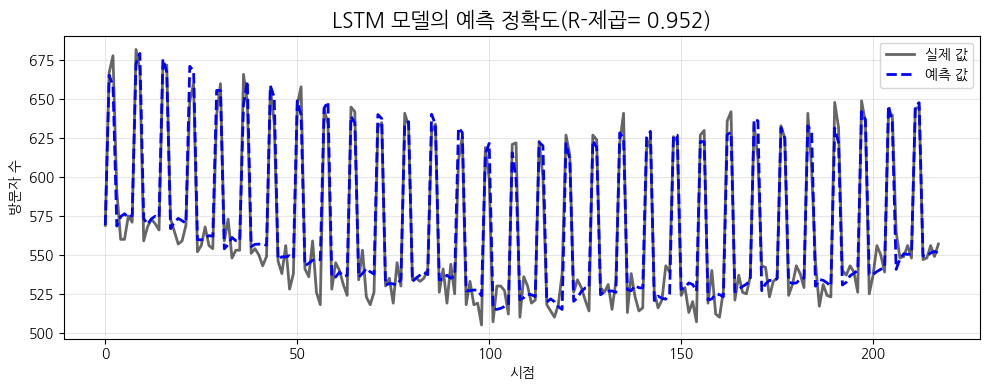

In [ ]:
# 검증 데이터에 대한 예측
y_pred = model.predict(x_test)
# 스케일 복구
y_test_inverse = scaler_mm.inverse_transform(y_test)
y_pred_inverse = scaler_mm.inverse_transform(y_pred)

R=r2_score(y_test, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_test_inverse, label='실제 값', color='black', linewidth=2, alpha=0.6)
plt.plot(y_pred_inverse, label='예측 값', color='blue', linestyle='--', linewidth=2)
plt.title(f"LSTM 모델의 예측 정확도(R-제곱={R: .3f})", fontsize=15)
plt.xlabel("시점"); plt.ylabel("방문자 수")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()